# Part B: Learned model
Train a landmark model that runs on CPU within a budget of **≤ 25 MB FP32 weights** and **≤ 20 ms per face crop** (median, batch size 1, single thread, on hardware you specify).

This is a ceiling rather than a target. It is set loosely enough that both heat-map and direct-coordinate formulations are reachable, so that the parameterization is your choice rather than something the budget decides. If you land well under it, state what you would spend the headroom on. Architecture, capacity, loss formulation, and coordinate parameterization are your decisions.

State your latency methodology: hardware, thread count, warm-up, number of runs, and how you handled variance. A millisecond on your machine is not a millisecond on ours, so the methodology and the reasoning about what you traded tell us more than the number does. If your hardware puts the ceiling out of reach, report that and justify your design point rather than compromising the model to hit it.

Report NME overall and per attribute subset.



## 준비: 라이브러리 + 설정

In [1]:
import sys, os
sys.path.append(os.path.abspath("../.."))

In [ ]:
from src.data.wflw_annotation_repository import parse_annotation
from src.shared.nme_metrics import nme_batch, report_by_subset
from src.models.landmark_net import LandmarkNet, count_params_mb
from src.application.eval_use_case import run_model
from src.settings import DataConfig, EvalConfig, ModelConfig, TrainConfig

import platform, time
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

In [3]:
data_config = DataConfig()
eval_config = EvalConfig()
model_config = ModelConfig()
train_config = TrainConfig()

REPO_ROOT = os.path.abspath("../..")

## 0. 모델 학습 (Part B 핵심)

학습 로직은 `src/application/train_use_case.py`(train/val 분리 + early
stopping + best 체크포인트 저장, `DESIGN.md` §3 참조)를 직접 호출.
이미 학습된 가중치가 있으면 `FORCE_RETRAIN=True`로 바꾸지 않는 한
재학습은 스킵(60 epoch 완주 시 ~30분 소요).

In [ ]:
import random
from src.application.train_use_case import split_train_val, train_model
from src.models.landmark_net import WingLoss

FORCE_RETRAIN = False
ckpt_path = os.path.abspath("../../output/weights/landmarknet.pt")

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

if FORCE_RETRAIN or not os.path.exists(ckpt_path):
    set_seed(42)
    train_dev = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print("[device] training on", train_dev)

    train_ds, val_ds = split_train_val(
        data_config.train_txt, data_config.images, model_config.input_size,
        seed=42, val_split=train_config.val_split, subsample=data_config.subsample)

    train_net = LandmarkNet(pretrained=model_config.pretrained).to(train_dev)
    crit = WingLoss() if train_config.loss == "wing" else torch.nn.SmoothL1Loss()

    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    train_model(train_net, train_ds, val_ds, crit, train_dev,
                epochs=train_config.epochs, lr=train_config.lr,
                batch_size=train_config.batch_size, ckpt_path=ckpt_path,
                patience=train_config.patience)
else:
    print(f"이미 학습된 가중치 사용: {ckpt_path} (재학습하려면 FORCE_RETRAIN=True)")

## 1. 모델 구조 + 파라미터 예산

MobileNetV3-small 백본 + FC head, 직접좌표 회귀(196=(x,y)×98, [0,1] 정규화).
파라미터화 선택 근거는 `src/models/landmark_net.py` 상단 docstring과 `DESIGN.md` §3/E-1 참조.

In [5]:
net = LandmarkNet(pretrained=False)
n, mb = count_params_mb(net)
print(f"params={n:,}  fp32={mb:.2f}MB  (budget 25MB, 여유 {25/mb:.1f}배)")

params=1,125,092  fp32=4.50MB  (budget 25MB, 여유 5.6배)


## 2. 지연(latency) 측정

방법론: CPU, `torch.set_num_threads(1)` (배포 예산이 CPU 단일 스레드 기준이므로
학습에 썼던 MPS가 아니라 여기서는 반드시 CPU로 벤치), warmup 20회, 측정 200회,
batch=1, 입력 128×128, median + IQR 리포트. 하드웨어: 본인 실행 환경에 맞게
`platform`/`sysctl`로 확인해 문서에 명시할 것 (이 저장소 기준 실측: Apple M3 Pro).

In [6]:
torch.set_num_threads(1)
net.eval()
x = torch.randn(1, 3, model_config.input_size, model_config.input_size)
with torch.no_grad():
    for _ in range(20):
        net(x)
    ts = []
    for _ in range(200):
        t0 = time.perf_counter()
        net(x)
        ts.append(time.perf_counter() - t0)
ts = np.array(ts) * 1e3

print("hardware:", platform.machine(), platform.system(), platform.mac_ver()[0])
print(f"latency median={np.median(ts):.1f}ms  IQR=[{np.percentile(ts,25):.1f}, "
      f"{np.percentile(ts,75):.1f}]ms  (budget 20ms)")

hardware: arm64 Darwin 15.7.3
latency median=8.2ms  IQR=[8.0, 9.3]ms  (budget 20ms)


## 3. NME 평가 (WFLW test 전체, 학습된 가중치로 실제 추론)

In [7]:
dev = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("[device] inference on", dev)

landmarknet_path = os.path.abspath("../../output/weights/landmarknet.pt")
net = LandmarkNet(pretrained=False).to(dev)
net.load_state_dict(torch.load(landmarknet_path, map_location=dev))

test = parse_annotation(data_config.test_txt, data_config.images)
gts, boxes, masks = test["landmarks"], test["bboxes"], test["subset_masks"]

preds = run_model(net, test["paths"], boxes, model_config.input_size, dev)
preds.shape

[device] inference on mps


(2500, 98, 2)

In [8]:
# 3종 정규화 x 전체/attribute subset. thr=0.10(문헌 관례) + Part D 배포기준 0.05도 함께.
def print_table(name, nmes, masks, thr):
    rows = report_by_subset(nmes, masks, thr)
    print(f"\n=== {name}  (thr={thr}) ===")
    print(f"{'subset':14s} {'NME':>8s} {'fail%':>8s}")
    for k, (m, fr) in rows.items():
        print(f"{k:14s} {m:8.4f} {fr*100:8.2f}")
    return rows


results_by_norm = {}
for norm in ["inter_ocular", "inter_pupil", "bbox_diag"]:
    nme, pp = nme_batch(preds, gts, norm, boxes)
    results_by_norm[norm] = (nme, pp)
    print_table(f"Part B (LandmarkNet) [{norm}]", nme, masks, eval_config.failure_threshold)

nme, pp = results_by_norm["inter_ocular"]
print_table("Part B @deploy thr=0.05", nme, masks, 0.05)


=== Part B (LandmarkNet) [inter_ocular]  (thr=0.1) ===
subset              NME    fail%
overall          0.1775    82.96
pose             0.3491   100.00
expression       0.1908    93.31
illumination     0.1666    79.94
make-up          0.1710    87.86
occlusion        0.1849    85.87
blur             0.1827    85.64

=== Part B (LandmarkNet) [inter_pupil]  (thr=0.1) ===
subset              NME    fail%
overall          0.2562    99.32
pose             0.5255   100.00
expression       0.2726   100.00
illumination     0.2377    98.85
make-up          0.2451   100.00
occlusion        0.2639    99.59
blur             0.2638    99.35

=== Part B (LandmarkNet) [bbox_diag]  (thr=0.1) ===
subset              NME    fail%
overall          0.0592     6.88
pose             0.0841    25.15
expression       0.0634     7.96
illumination     0.0579     6.02
make-up          0.0608     8.74
occlusion        0.0637    10.33
blur             0.0622     8.28

=== Part B @deploy thr=0.05  (thr=0.05) ===

{'overall': (0.1775454747527544, 1.0),
 'pose': (0.34911406036046416, 1.0),
 'expression': (0.19075994972488006, 1.0),
 'illumination': (0.16664414701487454, 1.0),
 'make-up': (0.17095863099565067, 1.0),
 'occlusion': (0.18488346416741686, 1.0),
 'blur': (0.1826928707858758, 1.0)}

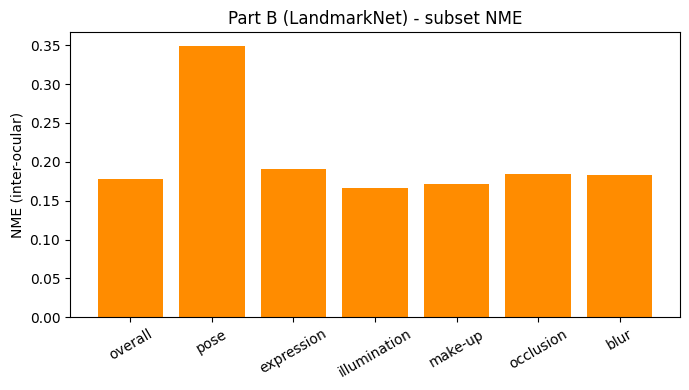

In [9]:
%matplotlib inline
# subset별 NME 막대그래프 (inter_ocular)
rows = report_by_subset(nme, masks, eval_config.failure_threshold)
names = list(rows.keys())
vals = [rows[k][0] for k in names]

plt.figure(figsize=(7, 4))
plt.bar(names, vals, color="darkorange")
plt.ylabel("NME (inter-ocular)")
plt.title("Part B (LandmarkNet) - subset NME")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

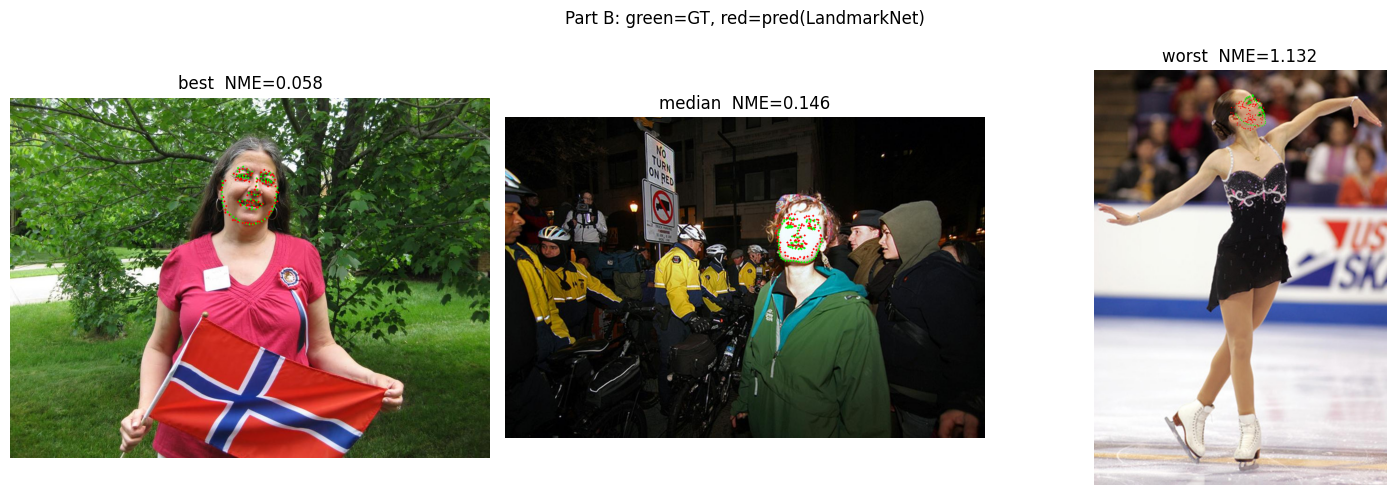

In [10]:
# 예측(빨간) vs 정답(초록) 오버레이: best / median / worst 3장
order = np.argsort(nme)
picks = {"best": order[0], "median": order[len(order)//2], "worst": order[-1]}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (tag, i) in zip(axes, picks.items()):
    img = cv2.cvtColor(cv2.imread(test["paths"][i]), cv2.COLOR_BGR2RGB).copy()
    for (x, y) in gts[i]:
        cv2.circle(img, (int(x), int(y)), 2, (0, 255, 0), -1)
    for (x, y) in preds[i]:
        cv2.circle(img, (int(x), int(y)), 2, (255, 0, 0), -1)
    ax.imshow(img)
    ax.set_title(f"{tag}  NME={nme[i]:.3f}")
    ax.axis("off")
fig.suptitle("Part B: green=GT, red=pred(LandmarkNet)")
fig.tight_layout()
plt.show()

## 4. output/results/preds.npz 생성 (Part C/D/E 공유 캐시)

Part A(mean-shape)도 함께 계산해 A/B 예측을 한 파일에 저장.
`src/notebooks/part_c.ipynb`, `part_d.ipynb`, `part_e.ipynb`가 이 파일을 참조.

In [ ]:
from src.application.baseline_use_case import compute_mean_shape, predict as predict_baseline

train = parse_annotation(data_config.train_txt, data_config.images)
mean_shape = compute_mean_shape(train["landmarks"], train["bboxes"])
preds_a = predict_baseline(mean_shape, boxes)

img_wh = np.array([cv2.imread(p).shape[1::-1] for p in test["paths"]])
results_dir = os.path.join(REPO_ROOT, "output", "results")
os.makedirs(results_dir, exist_ok=True)
np.savez(os.path.join(results_dir, "preds.npz"),
         predsA=preds_a, predsB=preds, gts=gts, boxes=boxes,
         attrs=test["attrs"], img_wh=img_wh, paths=np.array(test["paths"]))
print("saved ->", os.path.join(results_dir, "preds.npz"))